In [91]:
# ==========================================
# CELL 1 : IMPORT REQUIRED LIBRARIES
# ==========================================

# NumPy
# Used for numerical computations and matrix operations.
# We will use it for arrays, matrix multiplication,
# gradient descent, and the normal equation.

import numpy as np


# Pandas
# Used to work with tabular data (DataFrames).
# Makes it easy to access rows and columns.

import pandas as pd


# Matplotlib
# Used for plotting graphs and visualizations.

import matplotlib.pyplot as plt


# Load the California Housing dataset.
# fetch_california_housing() downloads (or loads if already cached)
# the dataset from scikit-learn.

from sklearn.datasets import fetch_california_housing


# Splits the dataset into training and testing sets.

from sklearn.model_selection import train_test_split


# StandardScaler standardizes features so they have
# mean = 0 and standard deviation = 1.

from sklearn.preprocessing import StandardScaler


# Evaluation metrics.
# MSE tells us the average prediction error.
# R² tells us how well the regression model explains the data.

from sklearn.metrics import mean_squared_error, r2_score

In [92]:
# ==========================================
# CELL 2 : LOAD THE DATASET
# ==========================================

# Fetch (download/load) the California Housing dataset.
#
# as_frame=True tells scikit-learn:
# "Return the data as Pandas DataFrames and Series
# instead of NumPy arrays."
#
# We choose this because DataFrames have column names
# like AveRooms, MedHouseVal, etc., making the data
# much easier to explore and understand.

california = fetch_california_housing(as_frame=True)


# The object returned is NOT a DataFrame.
# It is a "Bunch" object.
#
# A Bunch is similar to a dictionary/object that stores
# multiple pieces of information about the dataset:
#
# california.data          -> Feature table
# california.target        -> Target values
# california.feature_names -> List of feature names
# california.DESCR         -> Dataset description
# california.frame         -> Complete DataFrame (features + target)


# We store the complete table in a DataFrame named df.
#
# .frame combines all feature columns AND the target column
# into one table.

df = california.frame


# Display the first 5 rows of the dataset.
# head() is used only for inspection.
# It lets us verify that the dataset loaded correctly.

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [93]:
# ==========================================
# CELL 3 : SELECT INPUT (X) AND OUTPUT (y)
# ==========================================

# Machine Learning needs two things:
# X -> Input (Feature) : What the model learns FROM.
# y -> Output (Target) : What the model should PREDICT.

# This experiment asks for Linear Regression with ONE variable.
# So we choose only ONE feature: Average Rooms (AveRooms).

# Double brackets [['AveRooms']] return a DataFrame (2D table),
# not a Series (1D column).
# ML algorithms and NumPy matrix operations usually expect 2D data.

# .values converts the Pandas DataFrame into a NumPy array.
# We convert because later we'll perform mathematical operations
# (gradient descent, matrix multiplication) using NumPy.

X = df[['AveRooms']].values


# The target (answer) we want the model to predict
# is the Median House Value.

# Again, we use DOUBLE brackets so the result remains a
# DataFrame (2D), avoiding the need for reshape() later.

# If we had written:
# y = df['MedHouseVal'].values
# we'd get a 1D array with shape (20640,),
# and we'd have to convert it into a column vector using
# reshape(-1, 1).

y = df[['MedHouseVal']].values


# Check the dimensions of our data.

# shape = (rows, columns)

# Expected:
# X -> (20640, 1)
# 20640 houses
# 1 input feature (AveRooms)

# y -> (20640, 1)
# 20640 target values
# 1 output column (House Price)

# Printing the shapes acts as a quick sanity check.
# If the dimensions are wrong, we can catch mistakes
# before training the model.

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20640, 1)
y shape: (20640, 1)


In [94]:
# ==========================================
# CELL 4 : SPLIT THE DATASET
# ==========================================

# Before training the model, we divide the dataset into:
#
# Training Set -> Used to TRAIN (learn) the model.
# Testing Set  -> Used to TEST the model on unseen data.
#
# This helps us evaluate how well the model generalizes
# instead of simply memorizing the training data.


# --------------------------------------------------
# train_test_split()
#
# Syntax:
#
# train_test_split(X, y, ...)
#
# Returns FOUR values in the SAME ORDER:
#
# X_train -> Training input features
# X_test  -> Testing input features
# y_train -> Training target values
# y_test  -> Testing target values
#
# IMPORTANT:
# The order on the LEFT must match the order returned
# by train_test_split().
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    # 20% of the dataset is reserved for testing.
    # The remaining 80% is used for training.
    test_size=0.2,

    # Ensures the SAME random split every time
    # the notebook is executed.
    #
    # This makes the experiment reproducible and
    # keeps our results (theta, MSE, R², etc.)
    # consistent across runs.
    random_state=42

)


# --------------------------------------------------
# Verify the dimensions after splitting.
#
# Expected Shapes:
#
# X_train -> (16512, 1)
# y_train -> (16512, 1)
#
# X_test  -> (4128, 1)
# y_test  -> (4128, 1)
#
# Printing the shapes acts as a quick sanity check.
# If these dimensions are incorrect, later steps
# (scaling, training, prediction) may fail.
# --------------------------------------------------

print("X_train Shape :", X_train.shape)

print("y_train Shape :", y_train.shape)

print("X_test Shape  :", X_test.shape)

print("y_test Shape  :", y_test.shape)

X_train Shape : (16512, 1)
y_train Shape : (16512, 1)
X_test Shape  : (4128, 1)
y_test Shape  : (4128, 1)


In [95]:
# ==========================================
# OPTIONAL : EXPLORE THE DATASET
# (Just for your understanding, my dear)
# ==========================================

# This cell is OPTIONAL.
# It is not required for training the model.
# It simply helps you understand the dataset better.

# Display the first 5 rows of the dataset.
print("First 5 Rows:")
print(df.head())

# Display the number of rows and columns.
print("\nShape of Dataset:")
print(df.shape)

# Display all column names.
# These help us choose the feature (X)
# and the target (y).
print("\nColumns:")
print(df.columns)

# Check for missing (null) values.
# A value of 0 means there are no missing values
# in that column.
print("\nMissing Values:")
print(df.isnull().sum())

# Uncomment the line below if you're curious.
# It displays the complete description of the
# California Housing dataset (it's quite long!).
# print(california.DESCR)

First 5 Rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Shape of Dataset:
(20640, 9)

Columns:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
d

In [96]:
# ==========================================
# CELL 6 : FEATURE SCALING
# ==========================================

# Dear Tulip 🌷,
#
# Before our model starts learning, we need to prepare the data.
#
# Different features may have very different ranges.
# For example:
#
# Age        -> 20 to 80
# Salary     -> 20,000 to 2,00,000
# House Area -> 500 to 5000
#
# Features with much larger values can dominate the learning process.
# To prevent this, we STANDARDIZE the data using StandardScaler.
#
# StandardScaler transforms the data so that:
#
# Mean = 0
# Standard Deviation = 1
#
# This helps Gradient Descent converge faster and more reliably.


# --------------------------------------------------
# Create TWO separate StandardScaler objects.
#
# scaler_X -> Used for input features (X)
# scaler_y -> Used for target values (y)
#
# We keep them separate because X and y represent
# completely different quantities and have different scales.
# --------------------------------------------------

scaler_X = StandardScaler()
scaler_y = StandardScaler()


# --------------------------------------------------
# fit_transform()
#
# Step 1 : Learn the mean and standard deviation
#          from the TRAINING data.
#
# Step 2 : Use those values to standardize
#          the training data.
#
# IMPORTANT:
# We ALWAYS fit only on the training data.
# Never fit on the testing data, otherwise
# information from the test set leaks into
# the model (Data Leakage).
# --------------------------------------------------

X_train_scaled = scaler_X.fit_transform(X_train)


# --------------------------------------------------
# transform()
#
# DO NOT calculate a new mean and standard deviation.
#
# Instead, reuse the SAME values learned from
# X_train to scale X_test.
#
# This ensures that both datasets are scaled
# in exactly the same way.
# --------------------------------------------------

X_test_scaled = scaler_X.transform(X_test)


# --------------------------------------------------
# Scale the training target values.
#
# We also scale y because our implementation of
# Gradient Descent converges faster when both
# X and y are on similar scales.
#
# (In many sklearn examples y is left unscaled,
# but here we scale it because we're implementing
# Gradient Descent from scratch.)
# --------------------------------------------------

y_train_scaled = scaler_y.fit_transform(y_train)


# --------------------------------------------------
# Scale the testing target values using the SAME
# scaler that was fitted on the training targets.
#
# Never call fit_transform() on y_test.
# --------------------------------------------------

y_test_scaled = scaler_y.transform(y_test)


# --------------------------------------------------
# Verify that scaling has changed only the VALUES,
# not the SHAPE of the data.
#
# Expected Shapes:
#
# X_train_scaled -> (16512, 1)
# X_test_scaled  -> (4128, 1)
#
# y_train_scaled -> (16512, 1)
# y_test_scaled  -> (4128, 1)
# --------------------------------------------------

print("X_train_scaled Shape :", X_train_scaled.shape)

print("X_test_scaled Shape  :", X_test_scaled.shape)

print("y_train_scaled Shape :", y_train_scaled.shape)

print("y_test_scaled Shape  :", y_test_scaled.shape)

X_train_scaled Shape : (16512, 1)
X_test_scaled Shape  : (4128, 1)
y_train_scaled Shape : (16512, 1)
y_test_scaled Shape  : (4128, 1)


In [97]:
# ==========================================
# CELL 7 : ADD BIAS (INTERCEPT) COLUMN
# ==========================================

# 🌷 Look dear,
#
# Our Linear Regression equation is:
#
# y = θ₀ + θ₁x
#
# Matrix multiplication works best when every parameter
# is multiplied by an input value.
#
# Since θ₀ has no feature associated with it,
# we create a new feature x₀ = 1.
#
# This allows us to write the equation as:
#
# y = θ₀x₀ + θ₁x₁
#
# where x₀ is always 1.
#
# This is called adding the BIAS (or INTERCEPT) column.


# --------------------------------------------------
# Count the number of training samples.
#
# len(X_train_scaled) returns the number of rows
# (houses) in the training dataset.
# --------------------------------------------------

m = len(X_train_scaled)


# --------------------------------------------------
# np.ones((m,1))
#
# np.ones() creates an array filled with 1s.
#
# (m,1) means:
# m rows
# 1 column
#
# This becomes our Bias Column.
#
# np.c_[A, B]
#
# joins arrays COLUMN-WISE (side by side).
#
# So the first column becomes all 1s,
# followed by our scaled feature.
#
# Before:
#
# | x₁ |
#
# After:
#
# | 1  x₁ |
#
# The column of 1s represents x₀ = 1,
# allowing the model to learn θ₀ (the intercept)
# automatically.
# --------------------------------------------------

X_train_b = np.c_[np.ones((m,1)), X_train_scaled]


# --------------------------------------------------
# Add the SAME bias column to the testing data.
#
# Remember:
# The model expects the test data to have the
# EXACT same number of columns as the training data.
#
# We NEVER add a bias column to y because y is
# the OUTPUT (target), not an input feature.
# --------------------------------------------------

X_test_b = np.c_[

    np.ones((len(X_test_scaled),1)),

    X_test_scaled

    ]


# --------------------------------------------------
# Verify that exactly ONE new column has been added.
#
# Before:
# X_train_scaled -> (16512,1)
#
# After:
# X_train_b -> (16512,2)
#
# Only the number of columns changes.
# The number of rows remains the same.
# --------------------------------------------------

print("X_train_b Shape :", X_train_b.shape)

print("X_test_b Shape  :", X_test_b.shape)

X_train_b Shape : (16512, 2)
X_test_b Shape  : (4128, 2)


In [98]:
# ==========================================
# CELL 8 : NORMAL EQUATION
# ==========================================

# Lil G, the gradient Descent learns the parameters little by little.
#
# The Normal Equation, however, computes the BEST values
# of θ directly using matrix mathematics.
#
# No iterations.
# No learning rate.
# No repeated updates.
#
# It gives the optimal solution in ONE calculation
# (for small datasets).


# --------------------------------------------------
# Goal:
#
# Learn the best values of θ (theta),
#
# where:
#
# θ₀ -> Intercept (Bias)
# θ₁ -> Weight (Slope)
#
# Linear Regression Equation:
#
# y = θ₀ + θ₁x
#
# After adding the bias column:
#
# y = θ₀x₀ + θ₁x₁
#
# This lets us write everything in matrix form.
# --------------------------------------------------


# --------------------------------------------------
# Normal Equation
#
# θ = (XᵀX)⁻¹ Xᵀy
#
# where:
#
# Xᵀ
# → Transpose of X
# (Rows become columns.)
#
# XᵀX
# → Matrix multiplication.
#
# (XᵀX)⁻¹
# → Matrix inverse.
#
# Xᵀy
# → Matrix multiplication between Xᵀ and y.
#
# The result is the BEST parameter vector θ.
# --------------------------------------------------


# --------------------------------------------------
# IMPORTANT
#
# We ALWAYS train using ONLY the training dataset.
#
# Never use X_test or y_test while learning θ.
#
# Doing so would cause Data Leakage,
# because the model would indirectly learn from
# the testing data.
# --------------------------------------------------

theta_best = np.linalg.inv(

    X_train_b.T @ X_train_b

) @ X_train_b.T @ y_train_scaled


# --------------------------------------------------
# Explanation of the above line:
#
# X_train_b.T
#     ↓
# Compute Xᵀ
#
# X_train_b.T @ X_train_b
#     ↓
# Compute XᵀX
#
# np.linalg.inv(...)
#     ↓
# Compute (XᵀX)⁻¹
#
# @ X_train_b.T
#     ↓
# Multiply by Xᵀ
#
# @ y_train_scaled
#     ↓
# Multiply by y
#
# Final Result:
#
# θ = (XᵀX)⁻¹ Xᵀy
# --------------------------------------------------


# --------------------------------------------------
# theta_best stores the learned parameters.
#
# theta_best[0]
# → θ₀ (Intercept / Bias)
#
# theta_best[1]
# → θ₁ (Slope / Weight)
# --------------------------------------------------

print("Best Parameters (Theta):")

print(theta_best)

 # 🌷 Psst, Tulip...
#
# These are the parameters learned by the
# Normal Equation.
#
# Later, we'll compare them with the parameters
# learned by Gradient Descent.
#
# If both methods are implemented correctly,
# their predictions should be nearly identical.
#
# If they're wildly different...
# ...well, one of us definitely messed up 😅

Best Parameters (Theta):
[[4.81385765e-17]
 [1.58484867e-01]]


In [99]:
# ==========================================
# CELL 9 : INITIALIZE PARAMETERS
# ==========================================

# --------------------------------------------------
# LEARNING RATE (α) (it's kinda imp G)
#
# Controls how much θ changes in each iteration.
#
# Small Learning Rate
# → Slow but stable learning.
#
# Large Learning Rate
# → Faster learning but may overshoot the minimum
#   and fail to converge.
#
# Choosing a good learning rate is important for
# successful training.
# --------------------------------------------------

learning_rate = 0.01


# --------------------------------------------------
# ITERATIONS
#
# Number of times Gradient Descent updates θ.
#
# One iteration consists of:
#
# Predict
# → Compute Gradient
# → Update θ
# → Compute Cost
#
# This process repeats until the model learns
# the best parameters.
# --------------------------------------------------

iterations = 1500


# --------------------------------------------------
# INITIALIZE THETA
#
# Gradient Descent doesn't know the best values
# of θ initially.
#
# So we start with a simple guess:
#
# θ₀ = 0
# θ₁ = 0
#
# Since we have one feature, our model needs:
#
# θ₀ → Bias (Intercept)
# θ₁ → Weight (Slope)
#
# Therefore, theta has shape (2,1).
#
# np.zeros((2,1)) creates:
#
# [[0.]
#  [0.]]
#
# These values will gradually change during
# Gradient Descent.
# --------------------------------------------------

theta = np.zeros((2,1))


print("Initial Theta:")

print(theta)


Initial Theta:
[[0.]
 [0.]]


In [100]:
# ==========================================
# CELL 10 : COST FUNCTION
# ==========================================

# 🌷 My dear,
#
# How does the model know whether its predictions
# are GOOD or BAD?
#
# It needs a way to measure its mistakes.
#
# That measurement is called the COST FUNCTION.
#
# Think of it as the model's "Report Card."
#
# Lower Cost
# → Better predictions
#
# Higher Cost
# → Worse predictions.
#
# Gradient Descent repeatedly tries to MINIMIZE
# this cost by finding the best values of θ.


def compute_cost(X, y, theta):
    """
    Computes the Cost (Mean Squared Error).

    Parameters
    ----------
    X : Feature matrix with the bias column.
        (In our experiment -> X_train_b)

    y : Actual target values.
        (In our experiment -> y_train_scaled)

    theta : Current model parameters.
            (Current values of θ₀ and θ₁)

    Returns
    -------
    cost : A single value representing
           the prediction error.

           Lower Cost = Better Model
    """

    # --------------------------------------------------
    # Count the number of training examples.
    #
    # m = Number of houses (rows).
    # --------------------------------------------------

    m = len(y)


    # --------------------------------------------------
    # Make predictions using the current theta.
    #
    # Formula:
    #
    # Prediction = X × θ
    #
    # Matrix multiplication is performed using .dot().
    # --------------------------------------------------

    predictions = X.dot(theta)


    # --------------------------------------------------
    # Calculate the prediction error.
    #
    # Error = Prediction − Actual
    #
    # Positive Error
    # → Prediction is higher than the actual value.
    #
    # Negative Error
    # → Prediction is lower than the actual value.
    # --------------------------------------------------

    errors = predictions - y


    # --------------------------------------------------
    # Square every error.
    #
    # Why square?
    #
    # 1. Removes negative signs.
    # 2. Penalizes larger mistakes more heavily.
    # --------------------------------------------------

    squared_errors = errors ** 2


    # --------------------------------------------------
    # Add all squared errors together.
    # --------------------------------------------------

    total_squared_error = np.sum(squared_errors)


    # --------------------------------------------------
    # Compute the Cost.
    #
    # Cost Function:
    #
    #                 1
    # J(θ) = -------------------- Σ(prediction - actual)²
    #          2 × number of samples
    #
    #        1
    #      = ---- Σ(prediction - actual)²
    #        2m
    #
    # where:
    #
    # m
    # → Number of training examples.
    #
    # 2
    # → Included only to simplify differentiation.
    #   During Gradient Descent, the exponent's 2
    #   gets cancelled, making the gradient equation cleaner.
    # --------------------------------------------------

    cost = total_squared_error / (2 * m)

    # Equivalent one-line implementation:
    #
    # cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)

    return cost


# Fun Fact for 🌷 
#
# We don't call compute_cost() just once.
#
# Gradient Descent calls it after every update
# to check whether the model is improving.
#
# If the cost keeps decreasing,
# our model is learning correctly.

In [101]:
# ==========================================
# CELL 11 : GRADIENT DESCENT FUNCTION
# ==========================================

# So G☀️, this is where our model actually LEARNS.
# Unlike the Normal Equation, Gradient Descent
# does NOT know the best values of θ immediately.
#
# It starts with an initial guess and keeps improving
# θ little by little until the Cost becomes as small
# as possible.
#
# Every iteration follows these four steps:
#
# Predict
#    ↓
# Compute Gradient
#    ↓
# Update θ
#    ↓
# Compute Cost
#
# Then the process repeats.


# --------------------------------------------------
# Function to perform Gradient Descent.
#
# Parameters
# ----------
# X
# → Feature matrix (including the bias column).
#
# y
# → Actual target values.
#
# theta
# → Current model parameters (θ).
#
# learning_rate (α)
# → Controls how BIG each update is.
#
# iterations
# → Number of learning cycles.
#
#
# Returns
# -------
# theta
# → Final optimized parameters.
#
# cost_history
# → Stores the Cost after every iteration.
# --------------------------------------------------

def gradient_descent(X, y, theta, learning_rate, iterations):


    # --------------------------------------------------
    # Count the number of training examples.
    #
    # m = Number of houses (rows).
    # --------------------------------------------------

    m = len(y)


    # --------------------------------------------------
    # Empty list to store the Cost after every iteration.
    #
    # Later we'll plot this graph to check whether
    # the Cost is decreasing.
    # --------------------------------------------------

    cost_history = []


    # --------------------------------------------------
    # Repeat the learning process.
    #
    # One loop = One Iteration.
    # --------------------------------------------------

    for i in range(iterations):


        # --------------------------------------------------
        # Compute the Gradient.
        #
        # The Gradient answers one question:
        #
        # "How should θ change to reduce the Cost?"
        #
        # Formula:
        #
        # Gradient = (1/m) Xᵀ(Xθ − y)
        #
        #
        # Step 1
        # X.dot(theta)
        #
        # → Current Predictions.
        #
        #
        # Step 2
        # X.dot(theta) - y
        #
        # → Prediction Errors.
        #
        #
        # Step 3
        # X.T.dot(...)
        #
        # → Calculate how much EACH parameter
        # should change.
        #
        #
        # Step 4
        # Divide by m
        #
        # → Compute the Average Gradient.
        # --------------------------------------------------

        gradient = (1 / m) * X.T.dot(X.dot(theta) - y)


        # --------------------------------------------------
        # Update Theta.
        #
        # Formula:
        #
        # θ = θ − α × Gradient
        #
        # where:
        #
        # θ
        # → Current parameters.
        #
        # α
        # → Learning Rate.
        #
        # Gradient
        # → Direction in which the Cost
        # increases the fastest.
        #
        # Since we want to MINIMIZE the Cost,
        # we move in the OPPOSITE direction.
        # --------------------------------------------------

        theta = theta - learning_rate * gradient


        # --------------------------------------------------
        # Compute the Cost using the UPDATED theta.
        #
        # If everything is correct,
        # the Cost should slowly decrease.
        #
        # We store every Cost so we can later
        # visualize the learning process.
        # --------------------------------------------------

        cost_history.append(

            compute_cost(X, y, theta)

        )


    # --------------------------------------------------
    # Return:
    #
    # theta
    # → Final learned parameters.
    #
    # cost_history
    # → Cost after every iteration.
    # --------------------------------------------------

    return theta, cost_history

In [102]:
# ==========================================
# CELL 12 : TRAIN THE MODEL
# ==========================================

# Now that we've built the Gradient Descent function,
# let's use it to train our Linear Regression model.
#
# Until now, we've only defined HOW the model should learn.
# This function call actually starts the learning process.


# --------------------------------------------------
# Train the model using Gradient Descent.
#
# Arguments:
#
# X_train_b
# → Training feature matrix (including the bias column).
#
# y_train_scaled
# → Scaled target values.
#
# theta
# → Initial parameters (currently all zeros).
#
# learning_rate
# → Controls how much θ changes in each iteration.
#
# iterations
# → Number of learning iterations.
#
#
# Returns:
#
# theta_gd
# → Final optimized parameters.
#
# cost
# → Cost value after every iteration.
# --------------------------------------------------

theta_gd, cost = gradient_descent(

    X_train_b,

    y_train_scaled,

    theta,

    learning_rate,

    iterations

)


# --------------------------------------------------
# Display the learned parameters.
#
# theta_gd[0]
# → Learned Bias (θ₀)
#
# theta_gd[1]
# → Learned Weight (θ₁)
#
# These values should be very close to the
# parameters obtained using the Normal Equation.
# --------------------------------------------------

print("Theta learned by Gradient Descent:")

print(theta_gd)

# Compare:
#
# theta_best
#      vs
# theta_gd
#
# They don't have to be exactly identical,
# but they should be very close.
#
# If they are significantly different,
# revisit the Gradient Descent implementation.

Theta learned by Gradient Descent:
[[4.94046556e-17]
 [1.58484822e-01]]


In [103]:
# ==========================================
# CELL 13 : MAKE PREDICTIONS
# ==========================================

# 🌞 The model has finished learning.
#
# We now have the best values of θ (theta).
#
# Next, we use those learned parameters to
# predict house prices.
#
# Linear Regression Prediction Formula:
#
#            ŷ = Xθ
#
# where:
#
# X
# → Feature matrix (including the bias column)
#
# θ
# → Learned parameters
#
# ŷ
# → Predicted house prices


# ==================================================
# GRADIENT DESCENT PREDICTIONS
# ==================================================

# --------------------------------------------------
# Predict house prices for the TRAINING data.
#
# Why predict the training data?
#
# To check how well the model fits
# the data it learned from.
#
# X_train_b contains:
# • Bias column
# • Scaled Average Rooms
#
# theta_gd contains:
# • θ₀ (Bias)
# • θ₁ (Weight)
#
# Predictions are still in the SCALED form.
# --------------------------------------------------

y_pred_train_scaled = X_train_b.dot(theta_gd)


# --------------------------------------------------
# Predict house prices for the TEST data.
#
# These houses were NOT used during training.
#
# This helps us measure how well the model
# performs on unseen data.
#
# Predictions are still scaled.
# --------------------------------------------------

y_pred_test_scaled = X_test_b.dot(theta_gd)


# --------------------------------------------------
# Convert the predictions back to the ORIGINAL
# house price values.
#
# Why?
#
# During preprocessing we converted:
#
# y_train
#      ↓
# y_train_scaled
#
# Therefore the model naturally predicts
# scaled values.
#
# Humans understand ORIGINAL house prices,
# not standardized numbers.
#
# We use scaler_y because the model predicts
# ONLY the target (House Price).
#
# We DO NOT use scaler_X because the model
# never predicts the input feature.
# --------------------------------------------------

y_pred_train = scaler_y.inverse_transform(

    y_pred_train_scaled

)

y_pred_test = scaler_y.inverse_transform(

    y_pred_test_scaled

)



# ==================================================
# NORMAL EQUATION PREDICTIONS
# ==================================================

# --------------------------------------------------
# Predict house prices using the parameters learned
# by the Normal Equation.
#
# theta_best contains:
# • θ₀ (Bias)
# • θ₁ (Weight)
#
# Predictions are also in scaled form because
# theta_best was trained using y_train_scaled.
# --------------------------------------------------

y_pred_test_normal_scaled = X_test_b.dot(theta_best)


# --------------------------------------------------
# Convert the Normal Equation predictions
# back to the original house prices.
# --------------------------------------------------

y_pred_test_normal = scaler_y.inverse_transform(

    y_pred_test_normal_scaled

)



# ==================================================
# VERIFY THE SHAPES
# ==================================================

# Every input house should have exactly
# one predicted house price.

print("Training Predictions Shape           :", y_pred_train.shape)

print("Testing Predictions (GD) Shape       :", y_pred_test.shape)

print("Testing Predictions (Normal) Shape   :", y_pred_test_normal.shape)



# ==================================================
# Quick Summary
# ==================================================
#
# Gradient Descent
#
# y_pred_train_scaled
# → Training predictions (scaled)
#
# y_pred_test_scaled
# → Testing predictions (scaled)
#
# y_pred_train
# → Training predictions (original prices)
#
# y_pred_test
# → Testing predictions (original prices)
#
#
# Normal Equation
#
# y_pred_test_normal_scaled
# → Testing predictions (scaled)
#
# y_pred_test_normal
# → Testing predictions (original prices)
#
#
# We'll use the ORIGINAL predictions
# in the next cell to calculate:
#
# • Mean Squared Error (MSE)
# • R² Score

Training Predictions Shape           : (16512, 1)
Testing Predictions (GD) Shape       : (4128, 1)
Testing Predictions (Normal) Shape   : (4128, 1)


In [104]:
# ==========================================
# CELL 14 : MODEL EVALUATION
# ==========================================

# Our model has made its predictions.
#
# But are those predictions actually good?
#
# We now evaluate the model using two metrics:
#
# 1. Mean Squared Error (MSE)
# 2. R² Score


# --------------------------------------------------
# Mean Squared Error (MSE)
#
# Formula:
#
#                 1
# MSE = ---------------- Σ(actual - predicted)²
#         number of samples
#
# It measures the average squared difference
# between the actual and predicted values.
#
# Smaller MSE
# → Better model.
#
# MSE can never be negative.
#
# Perfect predictions
# → MSE = 0
# --------------------------------------------------


# --------------------------------------------------
# R² Score (Coefficient of Determination)
#
# Measures how well the regression model explains
# the variation in the target values.
#
# Range:
#
# R² = 1
# → Perfect prediction.
#
# R² = 0
# → Model is no better than predicting
#   the average value.
#
# R² < 0
# → Very poor model.
#
# Higher R²
# → Better model.
# --------------------------------------------------


# --------------------------------------------------
# Evaluate the Normal Equation model.
#
# Parameters:
#
# y_test
# → Actual house prices.
#
# y_pred_test_normal
# → House prices predicted using
#   the Normal Equation.
# --------------------------------------------------

mse_normal = mean_squared_error(

    y_test,

    y_pred_test_normal

)

r2_normal = r2_score(

    y_test,

    y_pred_test_normal

)


# --------------------------------------------------
# Evaluate the Gradient Descent model.
#
# Parameters:
#
# y_test
# → Actual house prices.
#
# y_pred_test
# → House prices predicted using
#   Gradient Descent.
# --------------------------------------------------

mse_gd = mean_squared_error(

    y_test,

    y_pred_test

)

r2_gd = r2_score(

    y_test,

    y_pred_test

)


# --------------------------------------------------
# Display the evaluation results.
#
# Ideally:
#
# • Low MSE
# • High R² (close to 1)
#
# Since both methods solve the same Linear
# Regression problem, their evaluation metrics
# should be nearly identical.
# --------------------------------------------------

print("===== NORMAL EQUATION =====")

print("Mean Squared Error (MSE) :", mse_normal)

print("R² Score                 :", r2_normal)

print()

print("===== GRADIENT DESCENT =====")

print("Mean Squared Error (MSE) :", mse_gd)

print("R² Score                 :", r2_gd)



# Compare the MSE and R² values.
#
# If the implementation is correct,
# the Normal Equation and Gradient Descent
# should produce almost the same results.
#
# Small differences are expected because
# Gradient Descent is an iterative approximation,
# while the Normal Equation computes the exact solution.

===== NORMAL EQUATION =====
Mean Squared Error (MSE) : 1.2923314440807299
R² Score                 : 0.013795337532284901

===== GRADIENT DESCENT =====
Mean Squared Error (MSE) : 1.2923314362391949
R² Score                 : 0.01379534351632139


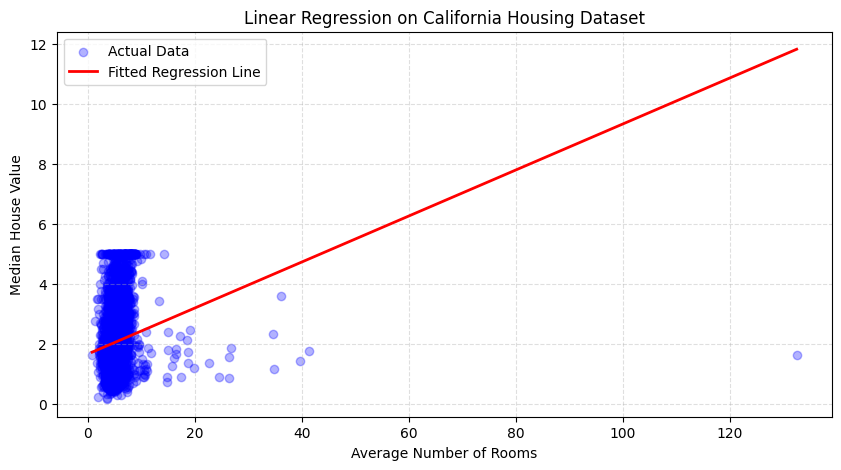

In [105]:
# ==========================================
# CELL 15 : VISUALIZE THE FITTED REGRESSION LINE
# ==========================================

# Until now, we've evaluated the model using
# numerical metrics like:
#
# • Mean Squared Error (MSE)
# • R² Score
#
# Those numbers tell us HOW GOOD the model is.
#
# Now we'll VISUALIZE the model.
#
# The graph will show:
#
# • Blue Dots  -> Actual House Prices
# • Red Line   -> Predicted Regression Line
#
# This makes it easier to understand how well
# the fitted line follows the overall trend
# of the data.


# --------------------------------------------------
# Sort the test feature values.
#
# Why?
#
# Matplotlib draws a line by connecting points
# in the order they are stored.
#
# Example:
#
# X values:
#
# 7  2  10  4
#
# Without sorting:
#
# 7 → 2 → 10 → 4
#
# The line becomes zig-zag.
#
# After sorting:
#
# 2 → 4 → 7 → 10
#
# The regression line becomes smooth.
#
# IMPORTANT:
#
# We are NOT changing the dataset.
#
# We are only changing the order in which
# the points are DRAWN.
# --------------------------------------------------

sorted_index = X_test[:,0].argsort()


# --------------------------------------------------
# Rearrange X values using the sorted indices.
# --------------------------------------------------

X_test_sorted = X_test[sorted_index]


# --------------------------------------------------
# Rearrange the predicted values in the EXACT
# same order.
#
# Otherwise the predictions and X values
# would no longer correspond to each other.
# --------------------------------------------------

y_pred_sorted = y_pred_test[sorted_index]


# --------------------------------------------------
# Create a new figure.
#
# figsize = (width,height)
#
# Units are inches.
#
# Larger figure = easier to read.
# --------------------------------------------------

plt.figure(figsize=(10,5))


# --------------------------------------------------
# Plot the ACTUAL data.
#
# scatter()
#
# Each dot represents ONE house.
#
# X-axis
# →
# Average Number of Rooms
#
# Y-axis
# →
# Median House Value
#
# alpha controls transparency.
#
# Smaller alpha
# →
# Easier to see overlapping points.
# --------------------------------------------------

plt.scatter(

    X_test,

    y_test,

    color="blue",

    alpha=0.3,

    label="Actual Data"

)


# --------------------------------------------------
# Plot the fitted regression line.
#
# plot()
#
# Unlike scatter(),
# plot() joins neighbouring points
# to create one continuous line.
#
# Here we're plotting the predictions
# produced by Gradient Descent.
# --------------------------------------------------

plt.plot(

    X_test_sorted,

    y_pred_sorted,

    color="red",

    linewidth=2,

    label="Fitted Regression Line"

)


# --------------------------------------------------
# Add a title.
#
# Helps explain what the graph represents.
# --------------------------------------------------

plt.title(

    "Linear Regression on California Housing Dataset"

)


# --------------------------------------------------
# Label the X-axis.
#
# Independent Variable (Feature)
# --------------------------------------------------

plt.xlabel(

    "Average Number of Rooms"

)


# --------------------------------------------------
# Label the Y-axis.
#
# Dependent Variable (Target)
# --------------------------------------------------

plt.ylabel(

    "Median House Value"

)


# --------------------------------------------------
# Display the legend.
#
# Without legend:
#
# We wouldn't know which colour
# represents what.
# --------------------------------------------------

plt.legend()


# --------------------------------------------------
# Display a light grid.
# Makes reading the graph easier.
# alpha controls transparency.
# --------------------------------------------------

plt.grid(
#u can avoid this shit if u want to
    True,

    linestyle="--",

    alpha=0.4

)


# --------------------------------------------------
# Finally display the graph.
#
# Until plt.show() is called,
# matplotlib keeps building the graph
# in memory.
#
# show()
# tells matplotlib:
#
# "Display everything now."
# --------------------------------------------------

plt.show()

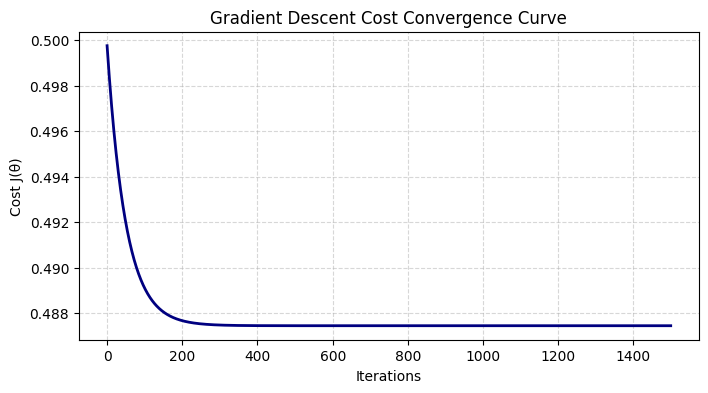

In [106]:
# ==========================================
# CELL 16 : GRADIENT DESCENT CONVERGENCE CURVE
# ==========================================

# Gradient Descent learns little by little.
#
# After every iteration,
# we stored the Cost in cost_history.
#
# This graph shows whether the Cost
# keeps decreasing during training.
#
# A steadily decreasing curve means
# Gradient Descent is learning correctly.


# --------------------------------------------------
# Create a new figure.
# --------------------------------------------------

plt.figure(figsize=(8,4))


# --------------------------------------------------
# Plot:
#
# X-axis
# → Iteration Number
#
# Y-axis
# → Cost Function J(θ)
#
# range(iterations)
# generates:
#
# 0, 1, 2, 3, ...
#
# cost_history stores:
#
# Cost₀
# Cost₁
# Cost₂
# ...
# --------------------------------------------------

plt.plot(

    range(iterations),

    cost,

    color="navy",

    linewidth=2

)


# --------------------------------------------------
# Add graph title and labels.
# --------------------------------------------------

plt.title("Gradient Descent Cost Convergence Curve")

plt.xlabel("Iterations")

plt.ylabel("Cost J(θ)")


# --------------------------------------------------
# Display grid.
# --------------------------------------------------

plt.grid(True, linestyle="--", alpha=0.5)


# Display the graph.
plt.show()